In [85]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [86]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [87]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt
from model.linear_model import LinearModel

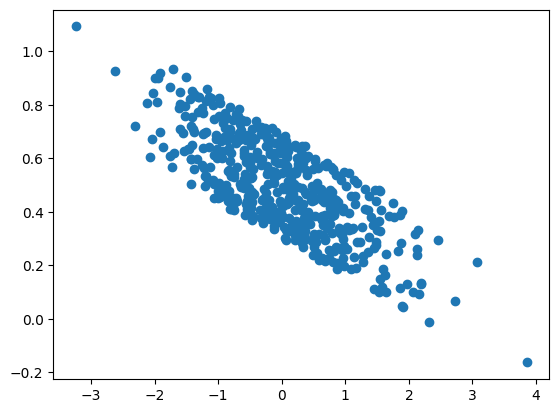

In [88]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [89]:
# Loading data
# loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

# X = loaded_data['X_data']
# y = loaded_data['y_data']
# W = loaded_data['W_data']

# # Show the size of data
# print(f"X size : {X.shape}, y size : {y.shape}")

# # Make sure size and dim correct.
# size = X.shape[0]
# dim = X.shape[1]-1

def load_data(tgt_dataset):
    loaded_data = np.load(f'data/linear_data/linear_data_{tgt_dataset}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']

    # Show the size of data
    print(f"X size : {X.shape}, y size : {y.shape}")

    # Make sure size and dim correct.
    size = X.shape[0]
    dim = X.shape[1]-1

    return X, y, W, size, dim


def train_model(tgt_dataset = "A", lr = 0.01, n_iteration = 500, val_ratio = 0.2, draw_scatter = False):
    # RANDOM SEED DECLEARED HERE
    seed = 42 # do not change the seed
    np.random.seed(seed)
    # read data
    X, y, W, size, dim = load_data(tgt_dataset)

    # Setting loss function and gradient. 
    loss_fn = MSE
    grad_fn = MSE_grad
    # split dataset into train and validation dataset
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    # set model and start training
    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=n_iteration, val_ratio=val_ratio)

    # evaluate the model
    y_val_pred = model.predict(X_val)
    evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title=f'Linear Regression Evaluation on dataset {tgt_dataset} dataset, lr={lr}')

    # draw scatter plot if needed
    if (draw_scatter):
        plt.figure(figsize=(5, 3))
        plt.scatter(X_val[:,1],y_val)
        plt.plot(X_val[:,1],y_val_pred)
        plt.show()

### Linear dataset A
#### lr = 0.1

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


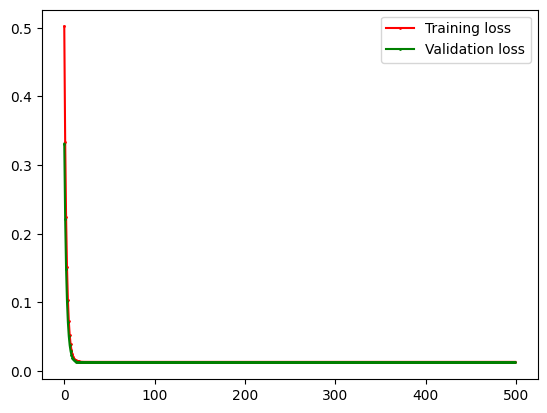

=== Linear Regression Evaluation on dataset A dataset, lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


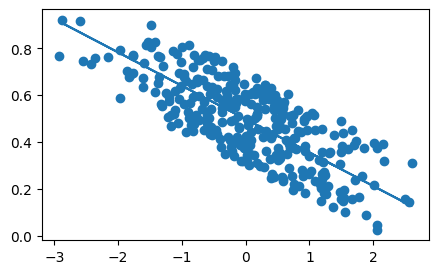

In [90]:
train_model(tgt_dataset="A",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.0882249976145924, Val loss:0.08344253861678509
100. Training loss: 0.024461533163063466, Val loss:0.022730598385935274
150. Training loss: 0.015054341888577382, Val loss:0.013961184271627125
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


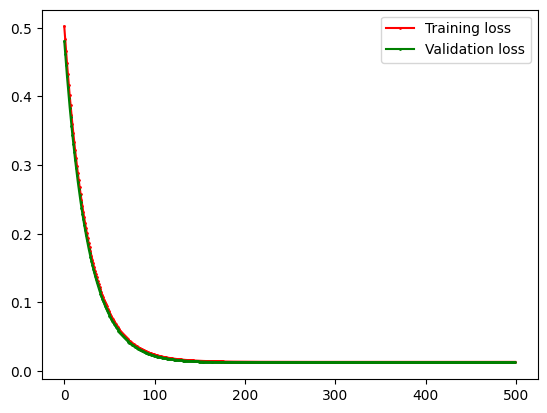

=== Linear Regression Evaluation on dataset A dataset, lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


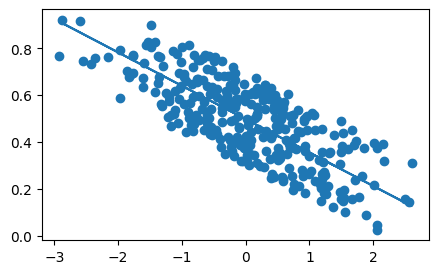

In [91]:
train_model(tgt_dataset="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.418984925274338, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937003, Val loss:0.3445251797643867
150. Training loss: 0.29083584025797743, Val loss:0.28691334687110637
200. Training loss: 0.24286379534660615, Val loss:0.23928338706190333
250. Training loss: 0.20319008395293747, Val loss:0.19990713434668123
300. Training loss: 0.17037874765339447, Val loss:0.1673555525025328
350. Training loss: 0.14324239869173927, Val loss:0.14044695514816508
400. Training loss: 0.12079917484937547, Val loss:0.11820419110090799
450. Training loss: 0.10223715148116819, Val loss:0.0998192422292796
500. Training loss: 0.08688491828078367, Val loss:0.08462395006505141


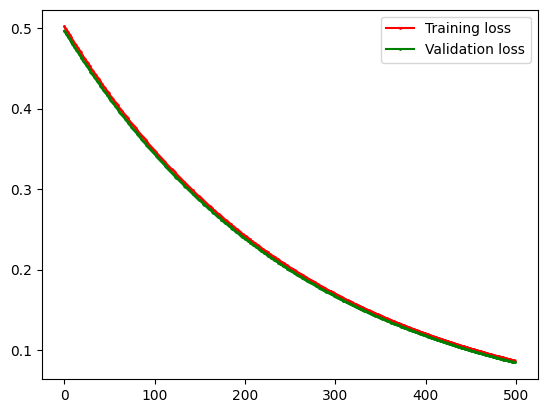

=== Linear Regression Evaluation on dataset A dataset, lr=0.001 ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836


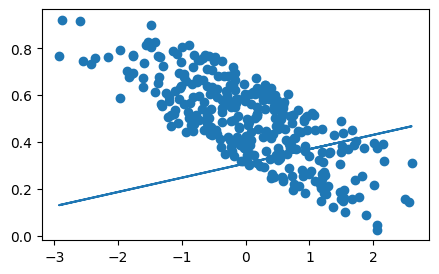

In [92]:
train_model(tgt_dataset="A",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset B
#### lr = 0.1

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.2147779602976193, Val loss:0.20128111574984847
100. Training loss: 0.21477795969579408, Val loss:0.20128143543301202
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


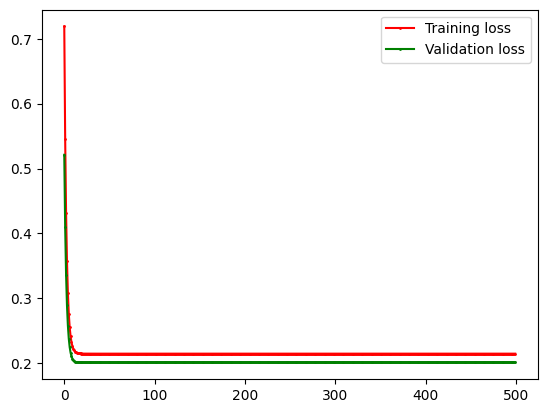

=== Linear Regression Evaluation on dataset B dataset, lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


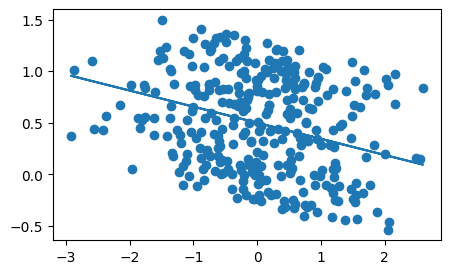

In [93]:
train_model(tgt_dataset="B",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.2920213425997664, Val loss:0.2702611408646165
100. Training loss: 0.2261837940753283, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342354
350. Training loss: 0.21477877162933798, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421996
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


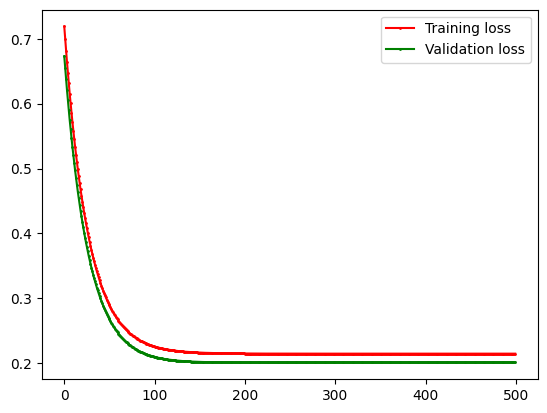

=== Linear Regression Evaluation on dataset B dataset, lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


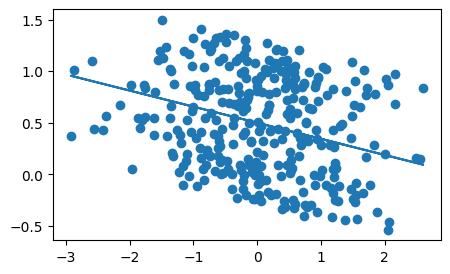

In [94]:
train_model(tgt_dataset="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.410669175541332, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.35485234230464696
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083345
450. Training loss: 0.3064845362852951, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


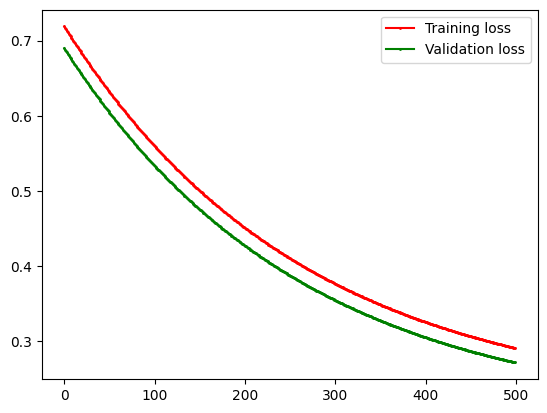

=== Linear Regression Evaluation on dataset B dataset, lr=0.001 ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011


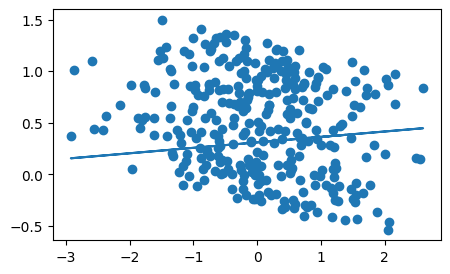

In [95]:
train_model(tgt_dataset="B",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset C
#### lr = 0.1

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422136, Val loss:0.013771595669720499
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


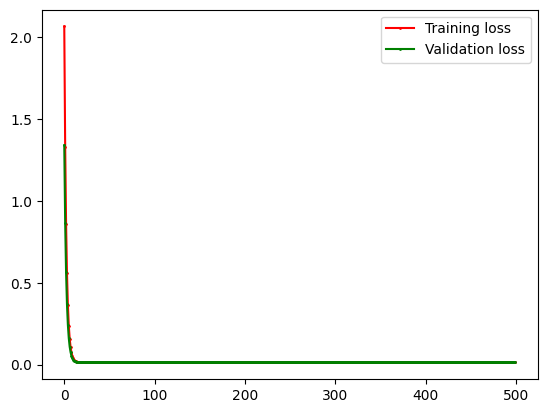

=== Linear Regression Evaluation on dataset C dataset, lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


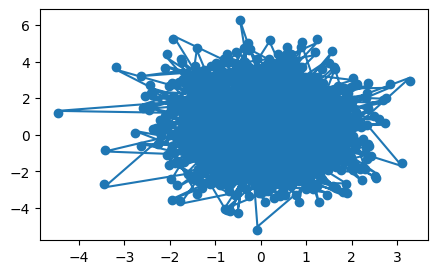

In [96]:
train_model(tgt_dataset="C",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.3016776572102271, Val loss:0.2940364008397444
100. Training loss: 0.052301281914569585, Val loss:0.052286225702638675
150. Training loss: 0.018505850726527058, Val loss:0.019175412162323584
200. Training loss: 0.01390898372103327, Val loss:0.014564896297918118
250. Training loss: 0.01328152198797338, Val loss:0.01389971244927915
300. Training loss: 0.01319558969139006, Val loss:0.01379609653511309
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772765
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770074
500. Training loss: 0.013181901150900588, Val loss:0.013771782558303797


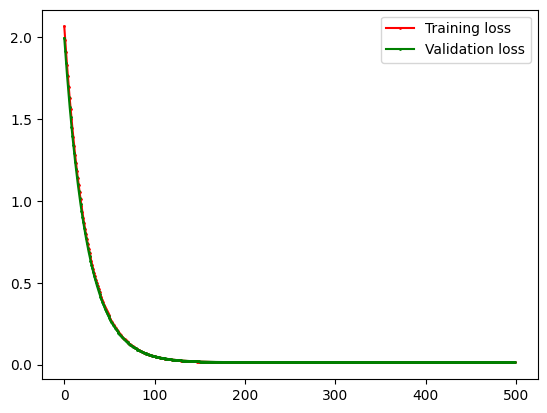

=== Linear Regression Evaluation on dataset C dataset, lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


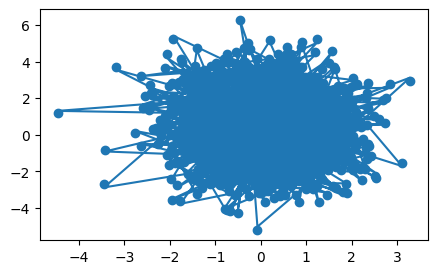

In [97]:
train_model(tgt_dataset="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 1.7022307356186883, Val loss:1.704399561902757
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081104, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803095, Val loss:0.7798533335010578
300. Training loss: 0.6393871949572305, Val loss:0.6424228534106732
350. Training loss: 0.526730101508695, Val loss:0.529687097137462
400. Training loss: 0.4343563650291916, Val loss:0.43720314708376407
450. Training loss: 0.35861115740443456, Val loss:0.3613282625111075
500. Training loss: 0.29649874274023025, Val loss:0.2990756308422207


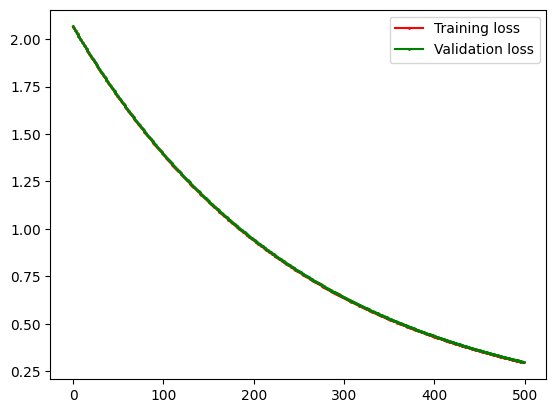

=== Linear Regression Evaluation on dataset C dataset, lr=0.001 ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994


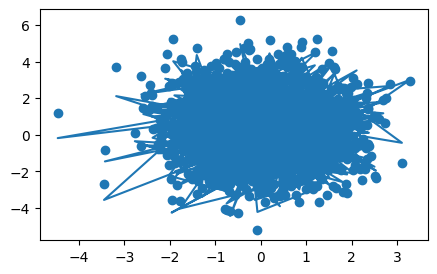

In [98]:
train_model(tgt_dataset="C",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset D
#### lr = 0.1

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
250. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
300. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
350. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
400. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
450. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
500. Training loss: 0.08238685077138833, Val loss:0.08607247293234568


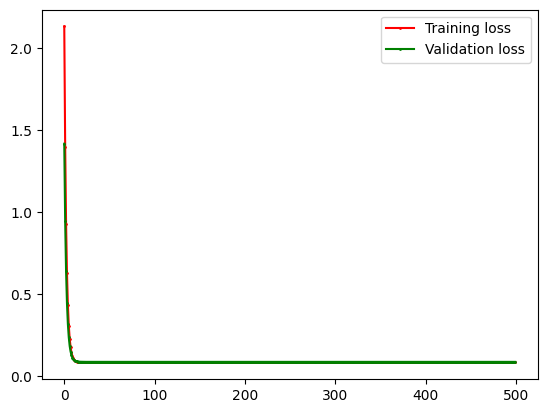

=== Linear Regression Evaluation on dataset D dataset, lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


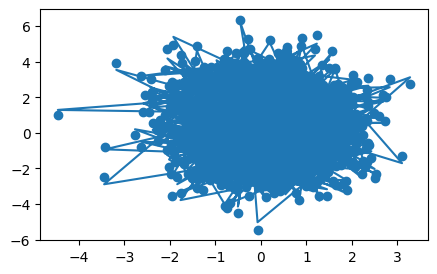

In [99]:
train_model(tgt_dataset="D",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.3703643487722048, Val loss:0.368684956398332
100. Training loss: 0.12143459698593073, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416796


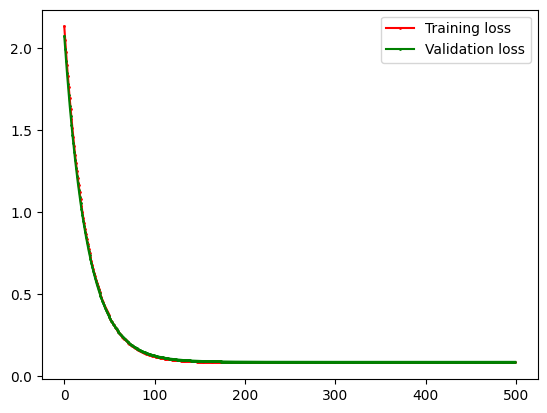

=== Linear Regression Evaluation on dataset D dataset, lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


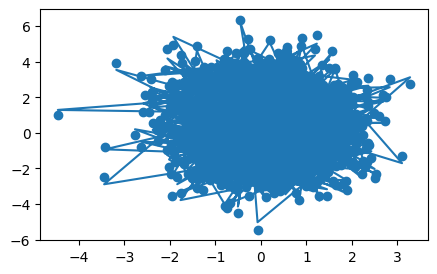

In [100]:
train_model(tgt_dataset="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.464852496414385, Val loss:1.4770554865390981
150. Training loss: 1.2159645145907352, Val loss:1.2278106296911488
200. Training loss: 1.0119199428934706, Val loss:1.0233353741451863
250. Training loss: 0.8446325767970517, Val loss:0.8555746535033417
300. Training loss: 0.7074755244845348, Val loss:0.7179245466593895
350. Training loss: 0.5950176249327073, Val loss:0.6049705693586134
400. Training loss: 0.5028075148402398, Val loss:0.512273209394556
450. Training loss: 0.42719672326568914, Val loss:0.43619216922708615
500. Training loss: 0.365194734037116, Val loss:0.3737423235472045


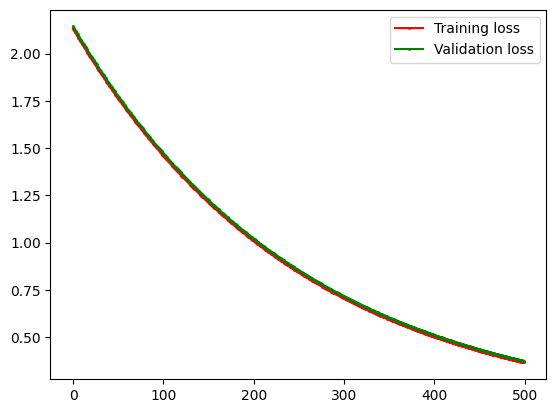

=== Linear Regression Evaluation on dataset D dataset, lr=0.001 ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


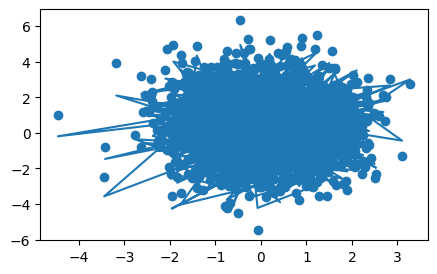

In [101]:
train_model(tgt_dataset="D",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

In [102]:
# # Train the model
# from model.linear_model import LinearModel

# seed = 42 # do not change the seed
# np.random.seed(seed)

# # Setting loss function and gradient. 
# loss_fn = MSE
# grad_fn = MSE_grad

# # Split dataset to train dataset and validation dataset
# X_train,y_train,X_val,y_val = get_train_val(X,y)

# # Setting model and starting training
# model = LinearModel(dim,True,loss_fn,grad_fn)
# model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [103]:
# # Get the Prediction
# y_val_pred = model.predict(X_val)

In [104]:
# # Evaluation 
# # Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
# evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

In [105]:
# # Plot
# plt.scatter(X_val[:,1],y_val)
# plt.plot(X_val[:,1],y_val_pred)
# plt.show()